In [1]:
import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('../01-data/processed/shopstream.db')

orders = pd.read_sql(
    'SELECT * FROM orders',
    conn
)

users = pd.read_sql(
    'SELECT * FROM users',
    conn
)

print("Orders:", orders.shape)
print("Users:", users.shape)

Orders: (125226, 9)
Users: (100000, 15)


In [2]:
orders['created_at'] = pd.to_datetime(
    orders['created_at'],
    format='mixed',
    utc=True
)

orders['order_month'] = (
    orders['created_at']
    .dt.to_period('M')
)

orders[['created_at','order_month']].head()

C:\Users\OM\AppData\Local\Temp\ipykernel_27744\3338111799.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period('M')


,created_at,order_month
0,2022-10-20 10:03:00+00:00,2022-10
1,2023-01-20 02:12:00+00:00,2023-01
2,2021-12-06 09:11:00+00:00,2021-12
3,2020-08-13 09:58:00+00:00,2020-08
4,2023-01-17 08:17:00+00:00,2023-01


In [3]:
first_purchase = (
    orders
    .groupby('user_id')['order_month']
    .min()
    .reset_index()
)

first_purchase.columns = [
    'user_id',
    'cohort_month'
]

first_purchase.head()

,user_id,cohort_month
0,1,2022-07
1,2,2022-02
2,3,2023-03
3,4,2022-10
4,5,2022-10


In [4]:
first_purchase.head()

,user_id,cohort_month
0,1,2022-07
1,2,2022-02
2,3,2023-03
3,4,2022-10
4,5,2022-10


In [5]:
orders_cohort = orders.merge(
    first_purchase,
    on='user_id',
    how='left'
)

orders_cohort.head()

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item,order_month,cohort_month
0,8,5,Cancelled,F,2022-10-20 10:03:00+00:00,None,None,None,3,2022-10,2022-10
1,60,44,Cancelled,F,2023-01-20 02:12:00+00:00,None,None,None,1,2023-01,2023-01
2,64,46,Cancelled,F,2021-12-06 09:11:00+00:00,None,None,None,1,2021-12,2020-08
3,89,65,Cancelled,F,2020-08-13 09:58:00+00:00,None,None,None,1,2020-08,2020-08
4,102,76,Cancelled,F,2023-01-17 08:17:00+00:00,None,None,None,2,2023-01,2022-11


In [6]:
orders_cohort[
    ['user_id','order_month','cohort_month']
].head()

,user_id,order_month,cohort_month
0,5,2022-10,2022-10
1,44,2023-01,2023-01
2,46,2021-12,2020-08
3,65,2020-08,2020-08
4,76,2023-01,2022-11


In [7]:
orders_cohort['period_number'] = (
    orders_cohort['order_month']
    - orders_cohort['cohort_month']
).apply(lambda x: x.n)

orders_cohort[
    [
        'user_id',
        'cohort_month',
        'order_month',
        'period_number'
    ]
].head(10)

,user_id,cohort_month,order_month,period_number
0,5,2022-10,2022-10,0
1,44,2023-01,2023-01,0
2,46,2020-08,2021-12,16
3,65,2020-08,2020-08,0
4,76,2022-11,2023-01,2
5,89,2023-07,2023-07,0
6,118,2020-04,2020-04,0
7,124,2022-07,2022-07,0
8,147,2024-01,2024-01,0
9,148,2023-07,2023-07,0


In [8]:
cohort_data = (

    orders_cohort

    .groupby(
        ['cohort_month','period_number']
    )['user_id']

    .nunique()

    .reset_index()

)

cohort_data.head(20)

,cohort_month,period_number,user_id
0,2019-01,0,22
1,2019-01,2,1
2,2019-01,7,1
3,2019-01,8,1
4,2019-01,16,1
5,2019-01,17,1
6,2019-01,19,1
7,2019-01,21,2
8,2019-01,27,1
9,2019-01,34,1


In [9]:
cohort_counts = cohort_data.pivot(

    index='cohort_month',

    columns='period_number',

    values='user_id'

)

cohort_counts.head()

period_number,0,1,2,3,4,5,6,7,8,9,...,49,50,51,52,53,54,55,56,57,58
cohort_month,,,,,,,,,,,,,,,,,,,,,
2019-01,22.0,NaN,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,...,NaN,1.0,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN
2019-02,37.0,NaN,NaN,NaN,2.0,2.0,2.0,NaN,2.0,NaN,...,NaN,1.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
2019-03,83.0,1.0,NaN,1.0,2.0,1.0,4.0,3.0,2.0,1.0,...,1.0,NaN,NaN,1.0,2.0,3.0,1.0,NaN,NaN,1.0
2019-04,103.0,2.0,1.0,2.0,1.0,2.0,2.0,NaN,2.0,4.0,...,3.0,1.0,1.0,1.0,NaN,3.0,NaN,2.0,2.0,NaN
2019-05,164.0,1.0,1.0,3.0,2.0,4.0,2.0,4.0,3.0,1.0,...,2.0,2.0,6.0,2.0,4.0,7.0,2.0,1.0,NaN,NaN


In [10]:
cohort_size = cohort_counts[0]

retention_matrix = cohort_counts.divide(
    cohort_size,
    axis=0
) * 100

retention_matrix = retention_matrix.iloc[:, :13]

retention_matrix.head()

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2019-01,100.0,NaN,4.545455,NaN,NaN,NaN,NaN,4.545455,4.545455,NaN,NaN,NaN,NaN
2019-02,100.0,NaN,NaN,NaN,5.405405,5.405405,5.405405,NaN,5.405405,NaN,2.702703,5.405405,2.702703
2019-03,100.0,1.204819,NaN,1.204819,2.409639,1.204819,4.819277,3.614458,2.409639,1.204819,6.024096,1.204819,NaN
2019-04,100.0,1.941748,0.970874,1.941748,0.970874,1.941748,1.941748,NaN,1.941748,3.883495,NaN,0.970874,NaN
2019-05,100.0,0.609756,0.609756,1.829268,1.219512,2.439024,1.219512,2.439024,1.829268,0.609756,1.829268,1.219512,NaN


In [11]:
retention_matrix.shape

(61, 13)

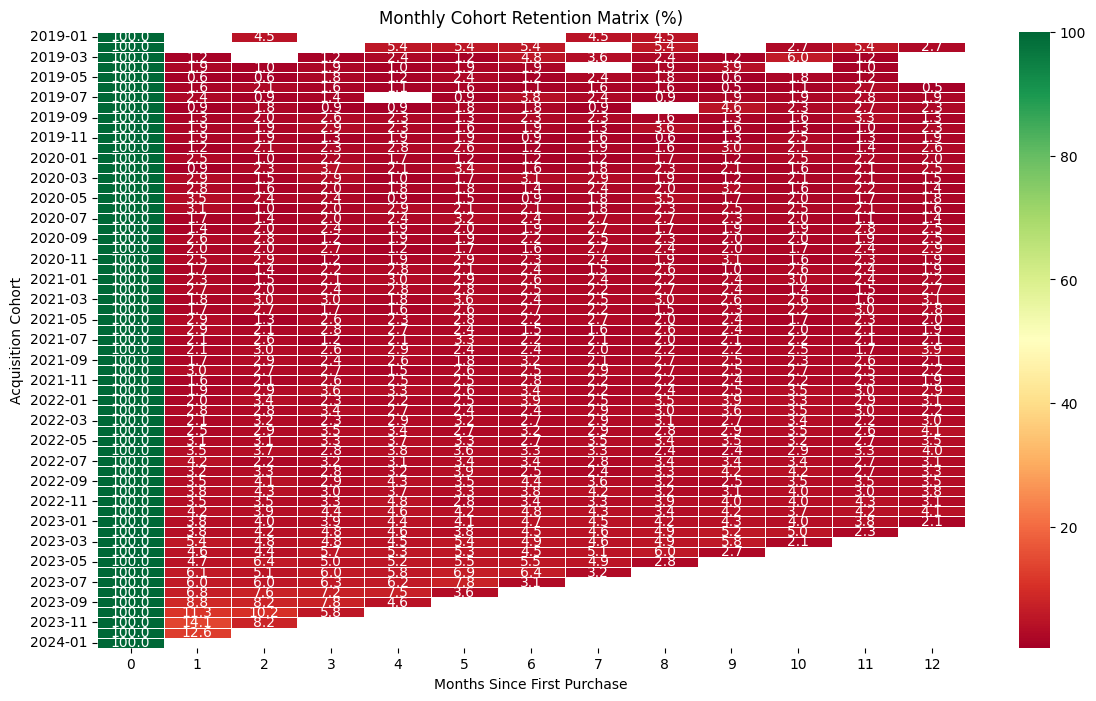

In [12]:
plt.figure(figsize=(14,8))

sns.heatmap(

    retention_matrix,

    annot=True,

    fmt=".1f",

    cmap="RdYlGn",

    linewidths=0.5

)

plt.title(
    "Monthly Cohort Retention Matrix (%)"
)

plt.xlabel(
    "Months Since First Purchase"
)

plt.ylabel(
    "Acquisition Cohort"
)

plt.show()

### Cohort Retention Analysis

Customer retention drops significantly after the first purchase month across all acquisition cohorts.

Most cohorts retain between 2% and 6% of customers after the first month, indicating a substantial early churn challenge.

Recent cohorts (2023 cohorts) show slightly stronger short-term retention performance compared to earlier cohorts, suggesting improvements in acquisition quality or customer experience.

The largest retention decline occurs immediately after Month 0, making the first 30 days the most critical period for customer engagement and retention interventions.

In [13]:
avg_retention = retention_matrix.mean()

avg_retention.head(13)

period_number
0     100.000000
1       3.375266
2       3.146922
3       3.012736
4       2.968072
5       2.934318
6       2.854566
7       2.717937
8       2.748092
9       2.622054
10      2.637220
11      2.438108
12      2.485556
dtype: float64

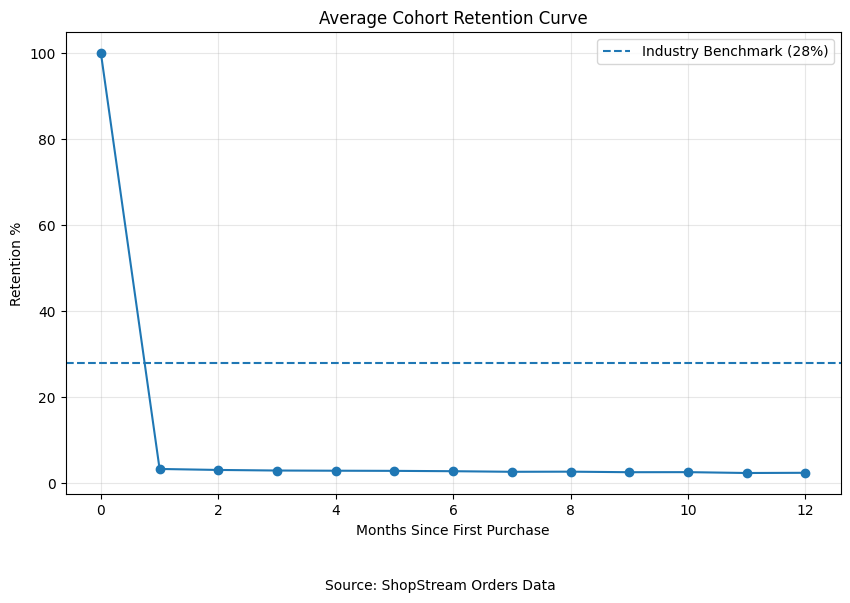

In [14]:
plt.figure(figsize=(10,6))

plt.plot(
    avg_retention.index,
    avg_retention.values,
    marker='o'
)

plt.axhline(
    y=28,
    linestyle='--',
    label='Industry Benchmark (28%)'
)

plt.title(
    'Average Cohort Retention Curve'
)

plt.xlabel(
    'Months Since First Purchase'
)

plt.ylabel(
    'Retention %'
)

plt.legend()

plt.grid(alpha=0.3)

plt.figtext(
    0.5,
    -0.05,
    'Source: ShopStream Orders Data',
    ha='center'
)

plt.show()

### Retention Curve Analysis

Average customer retention falls from 100% at acquisition to only 3.4% after the first month.

Retention remains relatively flat between 2% and 3% thereafter, indicating that customers who survive the initial churn period are more likely to remain active.

Compared to the industry benchmark of 28% retention, ShopStream significantly underperforms, highlighting customer retention as the company's largest growth opportunity.

The first month after acquisition should be treated as the primary intervention window for lifecycle marketing and customer engagement programs.

In [15]:
orders.columns

Index(['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at',
       'shipped_at', 'delivered_at', 'num_of_item', 'order_month'],
      dtype='object')

In [16]:
order_items = pd.read_sql(
    'SELECT * FROM order_items',
    conn
)

print(order_items.shape)

order_items.head()

(181759, 11)


,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,152013,104663,83582,14235,410368,Cancelled,2023-05-07 06:08:40+00:00,None,None,None,0.02
1,40993,28204,22551,14235,110590,Complete,2023-03-14 03:47:21+00:00,2023-03-15 22:57:00+00:00,2023-03-18 01:08:00+00:00,None,0.02
2,51224,35223,28215,14235,138236,Complete,2023-12-05 13:25:30+00:00,2023-12-06 01:20:00+00:00,2023-12-10 10:04:00+00:00,None,0.02
3,36717,25278,20165,14235,99072,Shipped,2023-12-22 20:48:19+00:00,2023-12-24 16:44:00+00:00,None,None,0.02
4,131061,90241,71954,14235,353798,Shipped,2022-06-19 16:57:59+00:00,2022-06-19 19:29:00+00:00,None,None,0.02


In [17]:
order_items.columns

Index(['id', 'order_id', 'user_id', 'product_id', 'inventory_item_id',
       'status', 'created_at', 'shipped_at', 'delivered_at', 'returned_at',
       'sale_price'],
      dtype='object')

In [18]:
ltv_data = order_items.merge(

    orders_cohort[
        [
            'order_id',
            'cohort_month',
            'period_number'
        ]
    ],

    on='order_id',
    how='left'

)

ltv_data.head()

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price,cohort_month,period_number
0,152013,104663,83582,14235,410368,Cancelled,2023-05-07 06:08:40+00:00,None,None,None,0.02,2023-04,1
1,40993,28204,22551,14235,110590,Complete,2023-03-14 03:47:21+00:00,2023-03-15 22:57:00+00:00,2023-03-18 01:08:00+00:00,None,0.02,2022-12,3
2,51224,35223,28215,14235,138236,Complete,2023-12-05 13:25:30+00:00,2023-12-06 01:20:00+00:00,2023-12-10 10:04:00+00:00,None,0.02,2022-08,16
3,36717,25278,20165,14235,99072,Shipped,2023-12-22 20:48:19+00:00,2023-12-24 16:44:00+00:00,None,None,0.02,2023-12,0
4,131061,90241,71954,14235,353798,Shipped,2022-06-19 16:57:59+00:00,2022-06-19 19:29:00+00:00,None,None,0.02,2022-06,0


In [19]:
cohort_revenue = (

    ltv_data

    .groupby(
        [
            'cohort_month',
            'period_number'
        ]
    )['sale_price']

    .sum()

    .reset_index()

)

cohort_revenue.head(20)

,cohort_month,period_number,sale_price
0,2019-01,0,2125.080007
1,2019-01,2,6.950000
2,2019-01,7,27.990000
3,2019-01,8,95.950001
4,2019-01,16,23.950001
5,2019-01,17,38.990002
6,2019-01,19,68.320004
7,2019-01,21,159.990000
8,2019-01,27,13.920000
9,2019-01,34,27.990000


In [20]:
cohort_sizes = (

    first_purchase

    .groupby('cohort_month')

    .size()

    .reset_index(name='cohort_size')

)

cohort_sizes.head()

,cohort_month,cohort_size
0,2019-01,22
1,2019-02,37
2,2019-03,83
3,2019-04,103
4,2019-05,164


In [21]:
cohort_revenue = cohort_revenue.merge(
    cohort_sizes,
    on='cohort_month'
)

cohort_revenue['ltv'] = (
    cohort_revenue['sale_price']
    /
    cohort_revenue['cohort_size']
)

cohort_revenue.head()

,cohort_month,period_number,sale_price,cohort_size,ltv
0,2019-01,0,2125.080007,22,96.594546
1,2019-01,2,6.950000,22,0.315909
2,2019-01,7,27.990000,22,1.272273
3,2019-01,8,95.950001,22,4.361364
4,2019-01,16,23.950001,22,1.088636


In [22]:
cohort_revenue = cohort_revenue.sort_values(
    ['cohort_month','period_number']
)

cohort_revenue['cumulative_ltv'] = (

    cohort_revenue

    .groupby('cohort_month')['ltv']

    .cumsum()

)

cohort_revenue.head(20)

,cohort_month,period_number,sale_price,cohort_size,ltv,cumulative_ltv
0,2019-01,0,2125.080007,22,96.594546,96.594546
1,2019-01,2,6.950000,22,0.315909,96.910455
2,2019-01,7,27.990000,22,1.272273,98.182728
3,2019-01,8,95.950001,22,4.361364,102.544091
4,2019-01,16,23.950001,22,1.088636,103.632728
5,2019-01,17,38.990002,22,1.772273,105.405000
6,2019-01,19,68.320004,22,3.105455,108.510455
7,2019-01,21,159.990000,22,7.272273,115.782728
8,2019-01,27,13.920000,22,0.632727,116.415455
9,2019-01,34,27.990000,22,1.272273,117.687728


In [23]:
ltv_12m = cohort_revenue[
    cohort_revenue['period_number'] <= 12
]

ltv_12m.head()

,cohort_month,period_number,sale_price,cohort_size,ltv,cumulative_ltv
0,2019-01,0,2125.080007,22,96.594546,96.594546
1,2019-01,2,6.950000,22,0.315909,96.910455
2,2019-01,7,27.990000,22,1.272273,98.182728
3,2019-01,8,95.950001,22,4.361364,102.544091
18,2019-02,0,4125.010007,37,111.486757,111.486757


In [24]:
top_cohorts = (

    ltv_12m

    .groupby('cohort_month')['cumulative_ltv']

    .max()

    .sort_values(ascending=False)

)

top_cohorts.head(10)

cohort_month
2022-12    135.045361
2019-02    134.348378
2023-02    131.444425
2023-03    129.687924
2023-01    128.220377
2022-11    127.546509
2022-10    126.785612
2022-09    126.033771
2023-04    126.020120
2023-06    124.572476
Freq: M, Name: cumulative_ltv, dtype: float64

In [25]:
ltv_matrix = ltv_12m.pivot(

    index='cohort_month',

    columns='period_number',

    values='cumulative_ltv'

)

ltv_matrix.head()

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2019-01,96.594546,NaN,96.910455,NaN,NaN,NaN,NaN,98.182728,102.544091,NaN,NaN,NaN,NaN
2019-02,111.486757,NaN,NaN,NaN,115.161892,119.335946,121.340000,NaN,128.015406,NaN,128.406757,133.138108,134.348378
2019-03,95.749518,96.809759,NaN,97.556747,99.686145,100.227470,104.795061,107.891205,110.421326,110.903133,117.053012,117.709639,NaN
2019-04,102.202525,104.428156,104.523981,105.407379,107.716797,109.265243,110.268641,NaN,111.122525,117.364175,NaN,117.703981,NaN
2019-05,89.352561,89.684207,90.016524,90.700915,92.715305,93.190549,93.531951,95.222317,95.971890,96.557195,97.786098,100.782683,NaN


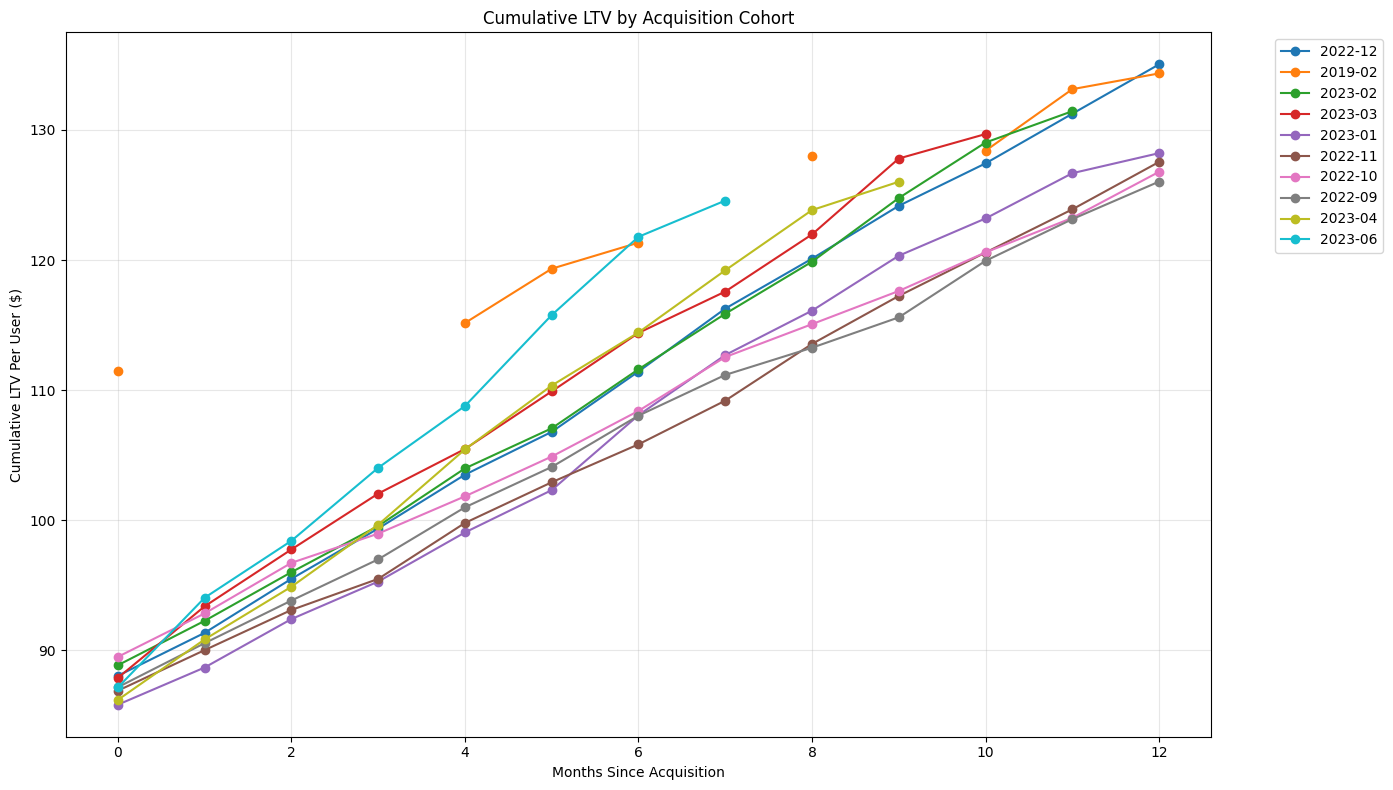

In [26]:
top10_cohorts = top_cohorts.head(10).index

plt.figure(figsize=(14,8))

for cohort in top10_cohorts:

    if cohort in ltv_matrix.index:

        plt.plot(

            ltv_matrix.columns,

            ltv_matrix.loc[cohort],

            marker='o',

            label=str(cohort)

        )

plt.title(
    'Cumulative LTV by Acquisition Cohort'
)

plt.xlabel(
    'Months Since Acquisition'
)

plt.ylabel(
    'Cumulative LTV Per User ($)'
)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### LTV Curve Analysis

The highest-value customer cohort was acquired in December 2022, generating approximately $135 of cumulative lifetime value per user within the first year.

Several 2022–2023 cohorts demonstrate consistently strong value creation, indicating improvements in acquisition quality and customer monetization.

Most customer lifetime value is generated during the acquisition month, with incremental gains occurring more slowly over subsequent months.

The business should analyze acquisition campaigns and customer characteristics from the highest-performing cohorts to replicate their success in future acquisition efforts.

In [27]:
events = pd.read_sql(
    'SELECT * FROM events',
    conn
)

print(events.shape)

(2431963, 13)


In [28]:
user_sessions = (

    events

    .groupby('user_id')['session_id']

    .nunique()

    .reset_index()

)

user_sessions.columns = [
    'user_id',
    'sessions'
]

user_sessions.head()

,user_id,sessions
0,1.0,3
1,2.0,1
2,3.0,5
3,4.0,1
4,5.0,3


In [29]:
purchase_counts = (

    orders

    .groupby('user_id')

    .size()

    .reset_index(name='orders')

)

purchase_counts.head()

,user_id,orders
0,1,1
1,2,1
2,3,4
3,4,1
4,5,1


In [30]:
churn_df = user_sessions.merge(
    purchase_counts,
    on='user_id',
    how='left'
)

churn_df['orders'] = churn_df['orders'].fillna(0)

churn_df.head()

,user_id,sessions,orders
0,1.0,3,1
1,2.0,1,1
2,3.0,5,4
3,4.0,1,1
4,5.0,3,1


In [31]:
print(churn_df.shape)

churn_df.describe()

(80044, 3)


,user_id,sessions,orders
count,80044.000000,80044.000000,80044.000000
mean,50046.153478,2.270739,1.564465
std,28860.502880,1.606249,0.862876
min,1.000000,1.000000,1.000000
25%,25059.750000,1.000000,1.000000
50%,50081.500000,2.000000,1.000000
75%,75007.500000,3.000000,2.000000
max,100000.000000,14.000000,4.000000


In [32]:
churn_df['churned'] = np.where(
    churn_df['orders'] == 1,
    1,
    0
)

churn_df['churned'].value_counts()

churned
1    49832
0    30212
Name: count, dtype: int64

In [33]:
session_churn = (

    churn_df

    .groupby('sessions')['churned']

    .agg(
        users='count',
        churn_probability='mean'
    )

    .reset_index()

)

session_churn['churn_probability'] = (
    session_churn['churn_probability'] * 100
)

session_churn

,sessions,users,churn_probability
0,1,34996,100.000000
1,2,19613,50.165706
2,3,9851,24.951782
3,4,7520,33.763298
4,5,4025,0.000000
5,6,1984,0.000000
6,7,1131,0.000000
7,8,561,0.000000
8,9,227,0.000000
9,10,88,0.000000


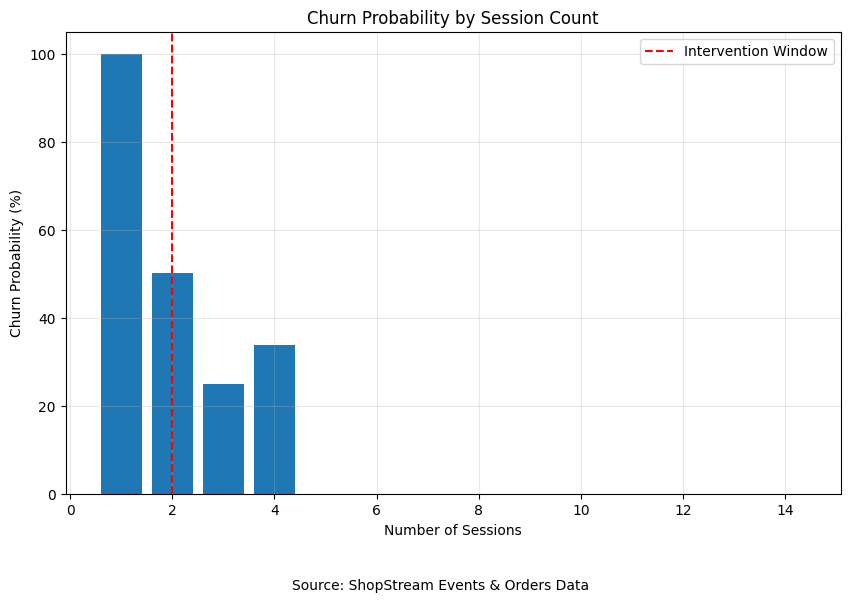

In [34]:
plt.figure(figsize=(10,6))

plt.bar(
    session_churn['sessions'],
    session_churn['churn_probability']
)

plt.axvline(
    x=2,
    color='red',
    linestyle='--',
    label='Intervention Window'
)

plt.title(
    'Churn Probability by Session Count'
)

plt.xlabel(
    'Number of Sessions'
)

plt.ylabel(
    'Churn Probability (%)'
)

plt.legend()

plt.grid(alpha=0.3)

plt.figtext(
    0.5,
    -0.05,
    'Source: ShopStream Events & Orders Data',
    ha='center'
)

plt.show()

### Churn Inflection Analysis

Users who do not return for a second session exhibit a 100% churn rate.

Churn probability falls to approximately 50% by Session 2 and 25% by Session 3.

This suggests that the first three customer sessions represent the most important retention window.

Lifecycle campaigns, onboarding emails, personalized recommendations, and promotional incentives should be concentrated during the first three sessions to maximize customer retention.

In [35]:
order_items['created_at'] = pd.to_datetime(
    order_items['created_at'],
    format='mixed',
    utc=True
)

latest_date = order_items['created_at'].max()

latest_date

Timestamp('2024-01-21 18:02:23.533893+0000', tz='UTC')

In [36]:
first_purchase_date = (

    orders

    .groupby('user_id')['created_at']

    .min()

    .reset_index()

)

first_purchase_date['created_at'] = pd.to_datetime(
    first_purchase_date['created_at'],
    format='mixed',
    utc=True
)

first_purchase_date['customer_age_months'] = (

    (latest_date - first_purchase_date['created_at'])

    .dt.days

    / 30

)

first_purchase_date.head()

,user_id,created_at,customer_age_months
0,1,2022-07-18 12:55:00+00:00,18.400000
1,2,2022-02-20 10:34:00+00:00,23.333333
2,3,2023-03-10 09:13:00+00:00,10.566667
3,4,2022-10-18 09:31:00+00:00,15.333333
4,5,2022-10-20 10:03:00+00:00,15.266667


In [37]:
first_purchase_date['loyalty_bucket'] = np.where(

    first_purchase_date['customer_age_months'] < 3,
    '<3 Months',

    np.where(
        first_purchase_date['customer_age_months'] < 6,
        '3-6 Months',
        '6+ Months'
    )

)

first_purchase_date['loyalty_bucket'].value_counts()

loyalty_bucket
6+ Months     57719
<3 Months     13440
3-6 Months     8885
Name: count, dtype: int64

In [38]:
revenue_split = order_items.merge(

    first_purchase_date[
        [
            'user_id',
            'loyalty_bucket'
        ]
    ],

    on='user_id',
    how='left'

)

revenue_split.head()

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price,loyalty_bucket
0,152013,104663,83582,14235,410368,Cancelled,2023-05-07 06:08:40+00:00,None,None,None,0.02,6+ Months
1,40993,28204,22551,14235,110590,Complete,2023-03-14 03:47:21+00:00,2023-03-15 22:57:00+00:00,2023-03-18 01:08:00+00:00,None,0.02,6+ Months
2,51224,35223,28215,14235,138236,Complete,2023-12-05 13:25:30+00:00,2023-12-06 01:20:00+00:00,2023-12-10 10:04:00+00:00,None,0.02,6+ Months
3,36717,25278,20165,14235,99072,Shipped,2023-12-22 20:48:19+00:00,2023-12-24 16:44:00+00:00,None,None,0.02,<3 Months
4,131061,90241,71954,14235,353798,Shipped,2022-06-19 16:57:59+00:00,2022-06-19 19:29:00+00:00,None,None,0.02,6+ Months


In [39]:
loyalty_revenue = (

    revenue_split

    .groupby('loyalty_bucket')['sale_price']

    .sum()

    .reset_index()

)

loyalty_revenue

,loyalty_bucket,sale_price
0,3-6 Months,1.084175e+06
1,6+ Months,8.185422e+06
2,<3 Months,1.557521e+06


In [40]:
total_revenue = loyalty_revenue['sale_price'].sum()

loyalty_revenue['revenue_pct'] = (
    loyalty_revenue['sale_price']
    / total_revenue
    * 100
)

loyalty_revenue

,loyalty_bucket,sale_price,revenue_pct
0,3-6 Months,1.084175e+06,10.013518
1,6+ Months,8.185422e+06,75.601112
2,<3 Months,1.557521e+06,14.385371


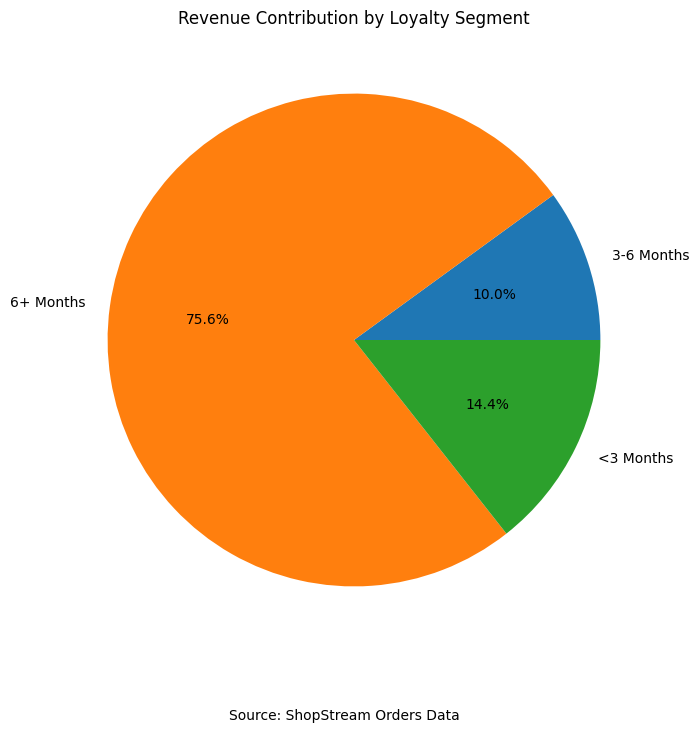

In [41]:
plt.figure(figsize=(8,8))

plt.pie(
    loyalty_revenue['sale_price'],
    labels=loyalty_revenue['loyalty_bucket'],
    autopct='%1.1f%%'
)

plt.title(
    'Revenue Contribution by Loyalty Segment'
)

plt.figtext(
    0.5,
    0.02,
    'Source: ShopStream Orders Data',
    ha='center'
)

plt.show()

### Loyalty Revenue Analysis

Customers with more than six months of tenure contribute approximately 76% of total revenue.

Recently acquired customers (<3 months) contribute only about 14% of revenue despite representing a substantial share of the customer base.

This indicates that long-term customer retention is the primary driver of business performance and profitability.

Increasing retention rates among newer customers could significantly improve future revenue growth and customer lifetime value.

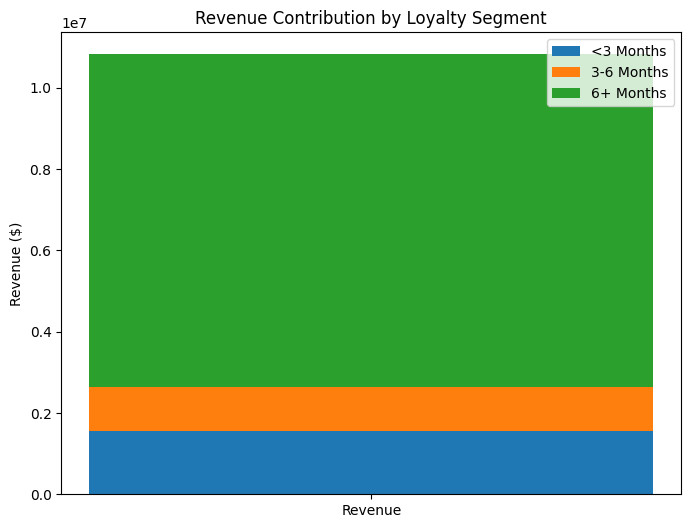

In [42]:
plt.figure(figsize=(8,6))

plt.bar(
    ['Revenue'],
    loyalty_revenue.loc[
        loyalty_revenue['loyalty_bucket']=='<3 Months',
        'sale_price'
    ].values[0],
    label='<3 Months'
)

plt.bar(
    ['Revenue'],
    loyalty_revenue.loc[
        loyalty_revenue['loyalty_bucket']=='3-6 Months',
        'sale_price'
    ].values[0],

    bottom=
    loyalty_revenue.loc[
        loyalty_revenue['loyalty_bucket']=='<3 Months',
        'sale_price'
    ].values[0],

    label='3-6 Months'
)

plt.bar(
    ['Revenue'],
    loyalty_revenue.loc[
        loyalty_revenue['loyalty_bucket']=='6+ Months',
        'sale_price'
    ].values[0],

    bottom=
    loyalty_revenue.loc[
        loyalty_revenue['loyalty_bucket']=='<3 Months',
        'sale_price'
    ].values[0]
    +
    loyalty_revenue.loc[
        loyalty_revenue['loyalty_bucket']=='3-6 Months',
        'sale_price'
    ].values[0],

    label='6+ Months'
)

plt.title('Revenue Contribution by Loyalty Segment')
plt.ylabel('Revenue ($)')
plt.legend()

plt.show()

In [45]:
products = pd.read_sql(
    "SELECT * FROM products",
    conn
)

products.head()

,id,cost,category,name,brand,retail_price,department,sku,distribution_center_id
0,13842,2.51875,Accessories,Low Profile Dyed Cotton Twill Cap - Navy W39S55D,MG,6.25,Women,EBD58B8A3F1D72F4206201DA62FB1204,1
1,13928,2.33835,Accessories,Low Profile Dyed Cotton Twill Cap - Putty W39S55D,MG,5.95,Women,2EAC42424D12436BDD6A5B8A88480CC3,1
2,14115,4.87956,Accessories,Enzyme Regular Solid Army Caps-Black W35S45D,MG,10.99,Women,EE364229B2791D1EF9355708EFF0BA34,1
3,14157,4.64877,Accessories,Enzyme Regular Solid Army Caps-Olive W35S45D (...,MG,10.99,Women,00BD13095D06C20B11A2993CA419D16B,1
4,14273,6.50793,Accessories,Washed Canvas Ivy Cap - Black W11S64C,MG,15.99,Women,F531DC20FDE20B7ADF3A73F52B71D0AF,1


In [46]:
products.columns

Index(['id', 'cost', 'category', 'name', 'brand', 'retail_price', 'department',
       'sku', 'distribution_center_id'],
      dtype='object')

In [47]:
category_orders = order_items.merge(
    products[['id', 'category']],
    left_on='product_id',
    right_on='id',
    how='left'
)

category_orders[['user_id','category']].head()

,user_id,category
0,83582,Accessories
1,22551,Accessories
2,28215,Accessories
3,20165,Accessories
4,71954,Accessories


In [48]:
user_category_orders = (

    category_orders

    .groupby(
        [
            'user_id',
            'category'
        ]
    )

    .size()

    .reset_index(name='purchase_count')

)

user_category_orders.head()

,user_id,category,purchase_count
0,1,Active,1
1,1,Blazers & Jackets,1
2,1,Jeans,1
3,2,Underwear,1
4,3,Active,1


In [49]:
repeat_category = (

    user_category_orders

    .groupby('category')

    .agg(

        total_users=('user_id','count'),

        repeat_buyers=(
            'purchase_count',
            lambda x: (x > 1).sum()
        )

    )

    .reset_index()

)

repeat_category['repeat_rate_pct'] = (

    repeat_category['repeat_buyers']
    /
    repeat_category['total_users']
    * 100

)

repeat_category = repeat_category.sort_values(
    'repeat_rate_pct',
    ascending=False
)

repeat_category.head(15)

,category,total_users,repeat_buyers,repeat_rate_pct
6,Intimates,11371,1816,15.970451
25,Underwear,6807,662,9.725283
12,Pants,6682,596,8.919485
7,Jeans,11669,951,8.149799
18,Socks,5835,472,8.089117
24,Tops & Tees,11010,850,7.720254
5,Fashion Hoodies & Sweatshirts,10991,830,7.551633
22,Sweaters,10418,783,7.515838
15,Shorts,10209,766,7.503183
21,Suits & Sport Coats,4848,355,7.322607


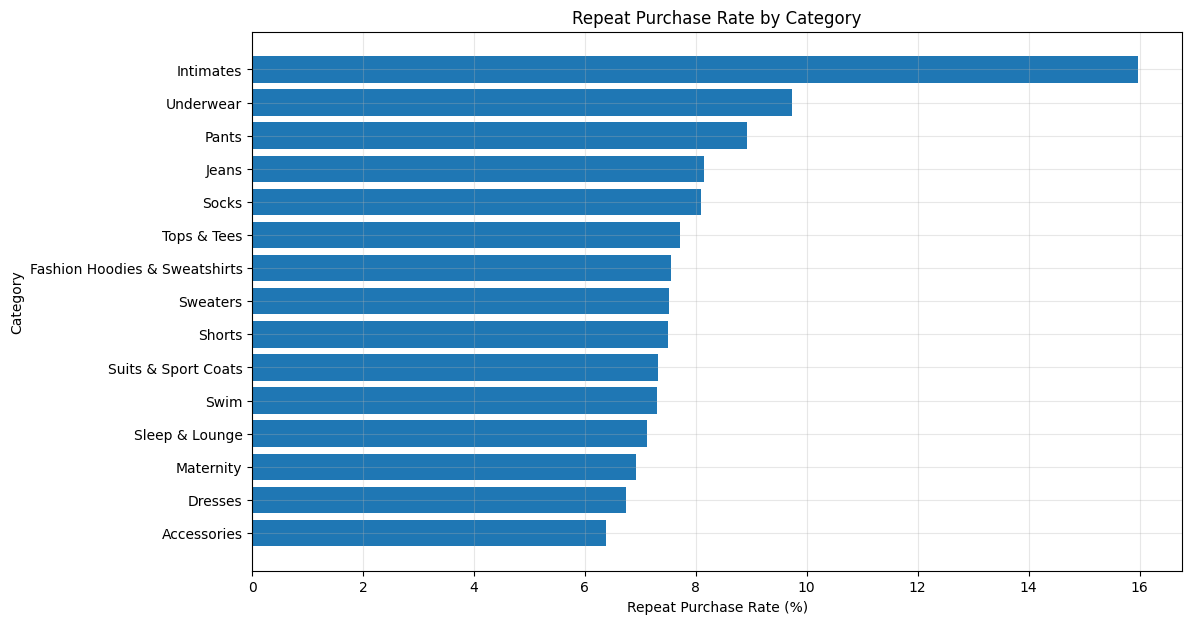

In [50]:
top_categories = repeat_category.head(15)

plt.figure(figsize=(12,7))

plt.barh(
    top_categories['category'],
    top_categories['repeat_rate_pct']
)

plt.gca().invert_yaxis()

plt.title(
    'Repeat Purchase Rate by Category'
)

plt.xlabel(
    'Repeat Purchase Rate (%)'
)

plt.ylabel(
    'Category'
)

plt.grid(alpha=0.3)

plt.show()

### Repeat Purchase Analysis

Intimates demonstrates the highest repeat purchase rate at 15.97%, significantly outperforming all other categories.

Basic apparel categories such as Underwear, Pants, Jeans, and Socks also show strong repeat purchasing behavior, indicating recurring customer demand.

These categories should receive priority for loyalty programs, subscription offerings, replenishment reminders, and cross-sell campaigns.

Accessories and Dresses exhibit lower repeat purchase rates, suggesting they behave more like occasional purchases rather than recurring-demand products.

In [51]:
survival_data = retention_matrix.iloc[:, :13]

survival_data.head()

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2019-01,100.0,NaN,4.545455,NaN,NaN,NaN,NaN,4.545455,4.545455,NaN,NaN,NaN,NaN
2019-02,100.0,NaN,NaN,NaN,5.405405,5.405405,5.405405,NaN,5.405405,NaN,2.702703,5.405405,2.702703
2019-03,100.0,1.204819,NaN,1.204819,2.409639,1.204819,4.819277,3.614458,2.409639,1.204819,6.024096,1.204819,NaN
2019-04,100.0,1.941748,0.970874,1.941748,0.970874,1.941748,1.941748,NaN,1.941748,3.883495,NaN,0.970874,NaN
2019-05,100.0,0.609756,0.609756,1.829268,1.219512,2.439024,1.219512,2.439024,1.829268,0.609756,1.829268,1.219512,NaN


In [52]:
avg_retention = survival_data.mean()

avg_retention

period_number
0     100.000000
1       3.375266
2       3.146922
3       3.012736
4       2.968072
5       2.934318
6       2.854566
7       2.717937
8       2.748092
9       2.622054
10      2.637220
11      2.438108
12      2.485556
dtype: float64

In [53]:
import numpy as np

cohort_count = survival_data.count()

std_retention = survival_data.std()

margin_error = (
    1.645
    *
    (
        std_retention
        /
        np.sqrt(cohort_count)
    )
)

lower_ci = avg_retention - margin_error
upper_ci = avg_retention + margin_error

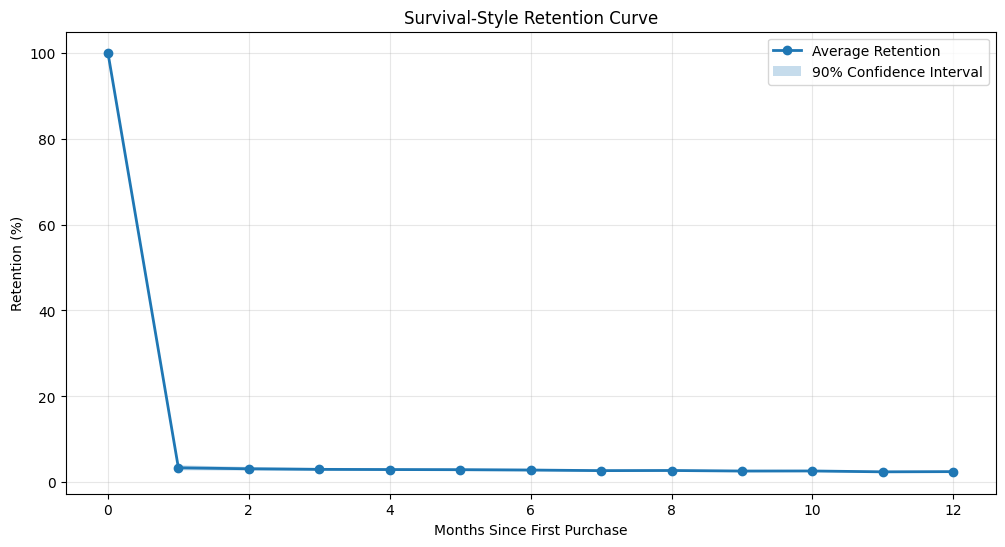

In [54]:
plt.figure(figsize=(12,6))

plt.plot(
    avg_retention.index,
    avg_retention.values,
    marker='o',
    linewidth=2,
    label='Average Retention'
)

plt.fill_between(

    avg_retention.index,

    lower_ci.values,

    upper_ci.values,

    alpha=0.25,

    label='90% Confidence Interval'

)

plt.title(
    'Survival-Style Retention Curve'
)

plt.xlabel(
    'Months Since First Purchase'
)

plt.ylabel(
    'Retention (%)'
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [55]:
retention_drop = avg_retention.diff()

retention_drop

period_number
0           NaN
1    -96.624734
2     -0.228344
3     -0.134186
4     -0.044664
5     -0.033755
6     -0.079752
7     -0.136628
8      0.030155
9     -0.126038
10     0.015165
11    -0.199112
12     0.047448
dtype: float64

In [56]:
retention_drop.idxmin()

1

### Survival Retention Analysis

Customer retention falls sharply after the acquisition month, indicating that the majority of churn occurs immediately after the first purchase.

After the initial decline, retention stabilizes within a narrow range, suggesting that customers who remain active beyond the first month are substantially more likely to continue purchasing.

The confidence interval remains relatively tight across later periods, indicating consistent retention behavior across cohorts.

The first month represents the most critical retention window and should be the primary focus of onboarding, engagement, and lifecycle marketing efforts.

In [1]:
import pandas as pd
import numpy as np

# Load orders
orders = pd.read_csv('../01-data/processed/cleaned_orders.csv')

# Parse dates
orders['created_at'] = pd.to_datetime(
    orders['created_at'],
    format='mixed',
    utc=True
)

# Keep required columns
cohort_df = orders[['user_id', 'created_at']].copy()

# Order Month
cohort_df['order_month'] = (
    cohort_df['created_at']
    .dt.to_period('M')
)

# First Purchase Month
cohort_df['cohort_month'] = (
    cohort_df.groupby('user_id')['order_month']
    .transform('min')
)

# Cohort Index
cohort_df['cohort_index'] = (
    (cohort_df['order_month'].dt.year -
     cohort_df['cohort_month'].dt.year) * 12
    +
    (cohort_df['order_month'].dt.month -
     cohort_df['cohort_month'].dt.month)
)

# Users per cohort
cohort_counts = (
    cohort_df
    .groupby(['cohort_month','cohort_index'])
    ['user_id']
    .nunique()
    .reset_index()
)

# Cohort Matrix
cohort_matrix = (
    cohort_counts
    .pivot(
        index='cohort_month',
        columns='cohort_index',
        values='user_id'
    )
)

# Retention %
cohort_size = cohort_matrix.iloc[:,0]

cohort_matrix = (
    cohort_matrix
    .divide(cohort_size, axis=0)
    * 100
)

# Save Output
cohort_matrix.to_csv(
    '../outputs/cohort_matrix.csv'
)

print("✅ cohort_matrix.csv created")
print(cohort_matrix.shape)

cohort_matrix.head()

✅ cohort_matrix.csv created
(61, 59)


C:\Users\OM\AppData\Local\Temp\ipykernel_27552\1385581128.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period('M')


cohort_index,0,1,2,3,4,5,6,7,8,9,...,49,50,51,52,53,54,55,56,57,58
cohort_month,,,,,,,,,,,,,,,,,,,,,
2019-01,100.0,NaN,4.545455,NaN,NaN,NaN,NaN,4.545455,4.545455,NaN,...,NaN,4.545455,NaN,4.545455,NaN,NaN,NaN,4.545455,NaN,NaN
2019-02,100.0,NaN,NaN,NaN,5.405405,5.405405,5.405405,NaN,5.405405,NaN,...,NaN,2.702703,NaN,NaN,NaN,5.405405,NaN,NaN,NaN,NaN
2019-03,100.0,1.204819,NaN,1.204819,2.409639,1.204819,4.819277,3.614458,2.409639,1.204819,...,1.204819,NaN,NaN,1.204819,2.409639,3.614458,1.204819,NaN,NaN,1.204819
2019-04,100.0,1.941748,0.970874,1.941748,0.970874,1.941748,1.941748,NaN,1.941748,3.883495,...,2.912621,0.970874,0.970874,0.970874,NaN,2.912621,NaN,1.941748,1.941748,NaN
2019-05,100.0,0.609756,0.609756,1.829268,1.219512,2.439024,1.219512,2.439024,1.829268,0.609756,...,1.219512,1.219512,3.658537,1.219512,2.439024,4.268293,1.219512,0.609756,NaN,NaN
